In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

from spd.data_utils import SparseFeatureDataset
from spd.experiments.resid_mlp.resid_mlp_dataset import ResidualMLPDataset
from spd.grouping import (
    CoactivationResults,
    get_coactivations,
    plot_clustering_from_results,
)
from spd.utils import get_device

# warnings.filterwarnings("ignore")

DEVICE = get_device()
print(f"Using device: {DEVICE = }")
torch.set_grad_enabled(False)

Using device: DEVICE = 'cuda'


In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

# TMS + identity

In [3]:
coactivations_tms: CoactivationResults = get_coactivations(
    model_path=Path("../data/tms-decomp/model_40000.pth"),
    dataset_cls=SparseFeatureDataset,
    dataset_kwargs=dict(
        value_range=(0.0, 1.0),
        synced_inputs=None,
    ),
    coactivations_kwargs=dict(
        module_groups=[["linear1", "linear2"]],
    ),
    device=DEVICE,
)
print(coactivations_tms.keys())

dict_keys(['group_0'])


Number of alive elements: 106
Number of clusters: 46
Cluster sizes: [ 3  2  1  3 16  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
  2  4  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  1  1  1]


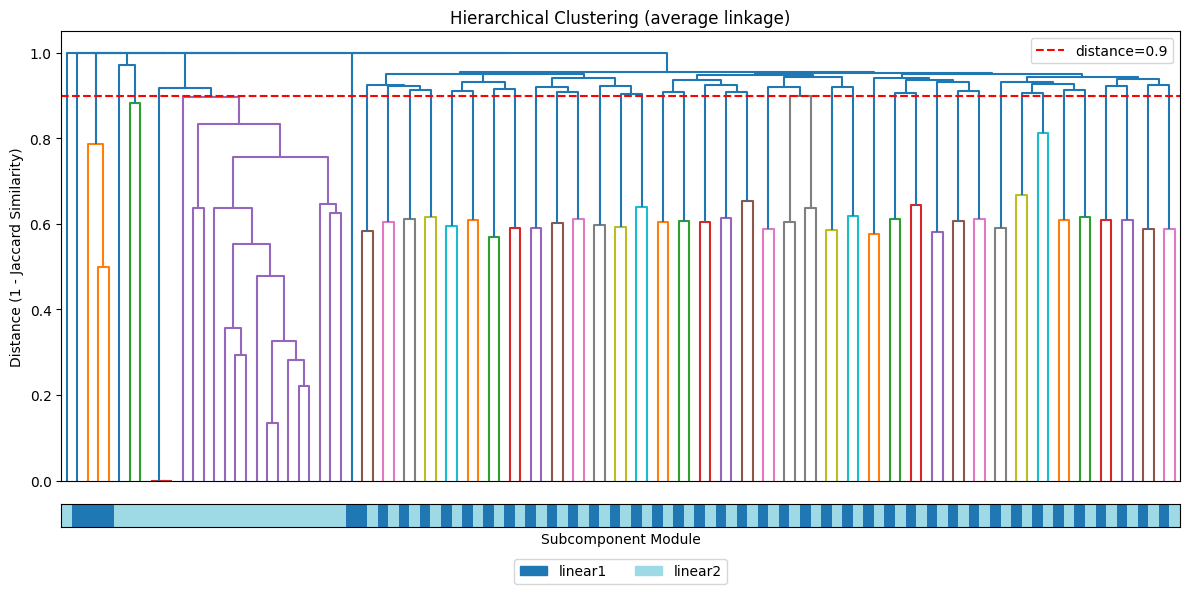

In [4]:
plot_clustering_from_results(
    results=coactivations_tms,
);

In [5]:
for group_key, group in coactivations_tms.items():
    print(f"{group_key = }:")
    for k, v in group.items():
        if isinstance(v, torch.Tensor):
            print(f"  {k}: {v.shape}")
        elif k == "labels":
            print(f"  labels: {set(v.tolist()) = }, {len(v) = }")
        else:
            print(f"  {k}: {v}")

group_key = 'group_0':
  co_occurrence_matrix: torch.Size([400, 400])
  marginal_counts: torch.Size([400])
  module_slices: {'linear1': slice(0, 200, None), 'linear2': slice(200, 400, None)}
  modules: ['linear1', 'linear2']
  labels: set(v.tolist()) = {'linear2', 'linear1'}, len(v) = 400
  total_samples: 500000
  activation_threshold: 0.1
  jaccard: torch.Size([400, 400])


In [6]:
from muutils.dbg import dbg_tensor
tms_coc = coactivations_tms["group_0"]["co_occurrence_matrix"].cpu()
tms_jac = coactivations_tms["group_0"]["jaccard"].cpu()
dbg_tensor(tms_coc)
dbg_tensor(tms_jac);

[ <ipykernel>:4 ] tms_coc: μ=147.14 σ=1294.98 x̃=0.00 R=[0.00,201677.00] ℙ=|█      | shape=(400,400) dtype=torch.float32 device=cpu ∇✗
[ <ipykernel>:5 ] tms_jac: μ=0.00 σ=0.03 x̃=0.00 R=[0.00,1.00] ℙ=|█      | shape=(400,400) dtype=torch.float32 device=cpu ∇✗


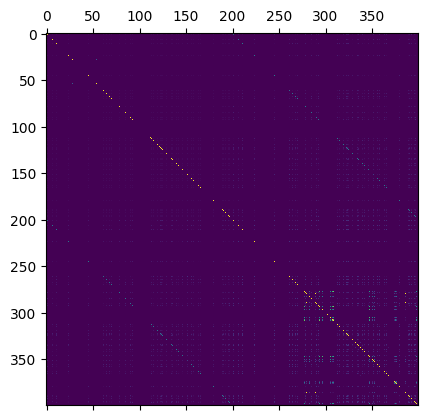

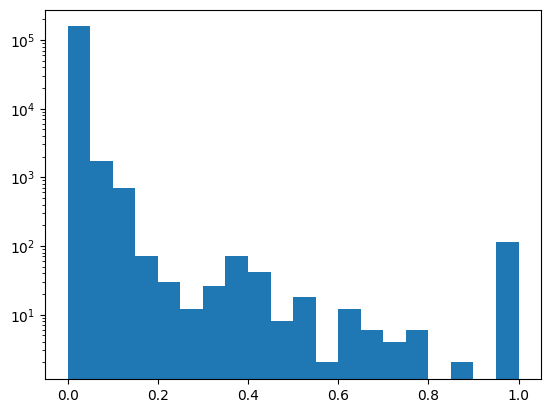

In [7]:
plt.matshow(tms_jac, cmap="viridis")
plt.show()
plt.hist(tms_jac.flatten(), bins=20)
plt.yscale("log")
plt.show()

In [ ]:
# Assume dist is the distance matrix from above
dbg_tensor(tms_jac)
tms_dist = 1/(tms_jac+1e-8)
dbg_tensor(tms_dist)
embedding_umap = UMAP(metric="precomputed").fit_transform(tms_dist)
embedding_isomap = Isomap(metric="precomputed").fit_transform(tms_dist)

/home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[ <ipykernel>:5 ] tms_jac: μ=0.00 σ=0.03 x̃=0.00 R=[0.00,1.00] ℙ=|█      | shape=(400,400) dtype=torch.float32 device=cpu ∇✗
[ <ipykernel>:7 ] tms_dist: μ=94486488.00 σ=22823852.00 x̃=100000000.00 R=[1.00,100000000.00] ℙ=|      █| shape=(400,400) dtype=torch.float32 device=cpu ∇✗
/home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")

/home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 

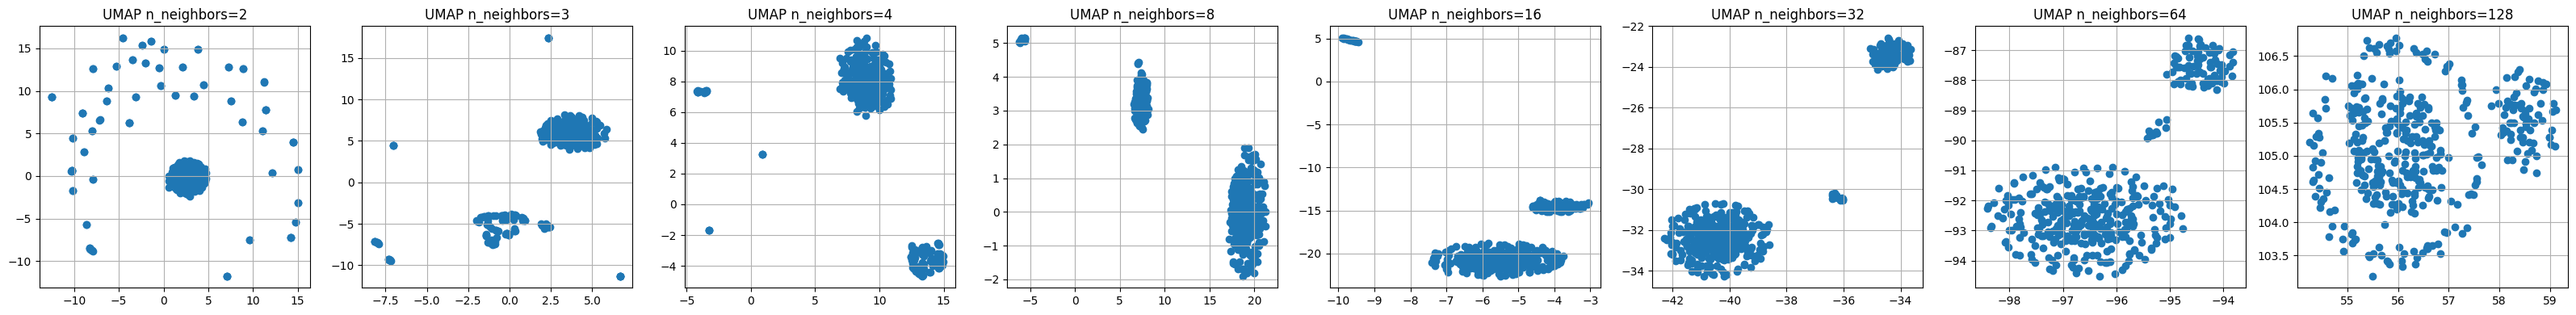

/home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 5 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


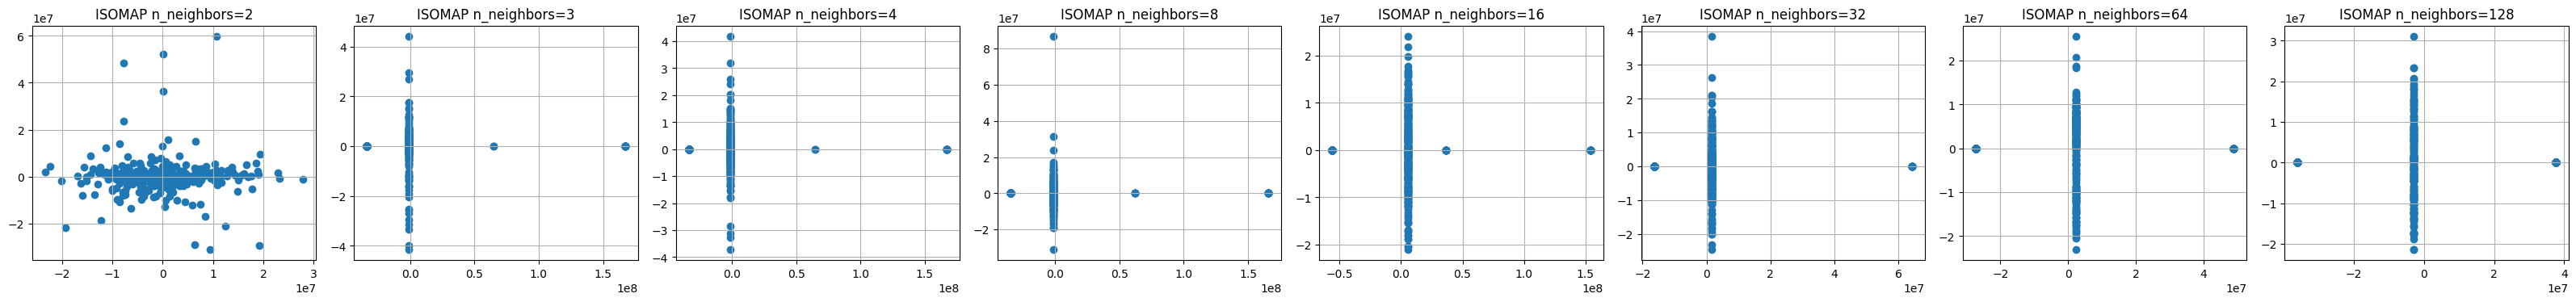

In [14]:
# Global literal and param value types
from typing import Literal, Sequence, Union, Any
from dataclasses import dataclass
import numpy as np
from sklearn.base import TransformerMixin
from sklearn.manifold import TSNE, Isomap
from umap import UMAP
from jaxtyping import Float

# TODO: this is ugly af
NDArray = np.ndarray[Any, Any]

ReduceMethod = Literal["umap", "isomap", "tsne"]
ParamValue = Union[int, float, str]

@dataclass
class EmbeddingResult:
    method: ReduceMethod
    param_name: str
    param_values: list[ParamValue]
    embeddings: dict[str, Float[NDArray, "n_components n_features"]]


def get_embedding_model(
    method: ReduceMethod,
    kwargs: dict[str, Any],
    n_components: int = 2,
    random_state: int = 42
) -> TransformerMixin:
    """Return configured embedding model."""
    if method == "umap":
        return UMAP(n_components=n_components, metric="precomputed", random_state=random_state, **kwargs) # type: ignore
    elif method == "isomap":
        return Isomap(n_components=n_components, metric="precomputed", **kwargs)
    elif method == "tsne":
        return TSNE( # type: ignore
            n_components=n_components,
            metric="precomputed",
            random_state=random_state,
            init="random",
            learning_rate="auto",
            **kwargs
        )
    raise ValueError(f"Unsupported method: {method}")


def compute_embedding_sweep(
    dist: NDArray,
    method: ReduceMethod,
    param_grid: list[dict[str, Any]],
    n_components: int = 2,
    random_state: int = 42
) -> dict[str, NDArray]:
    """Compute embeddings for a grid of parameter dicts."""
    embeddings: dict[str, NDArray] = {}
    for kwargs in param_grid:
        key: str = "_".join(f"{k}={v}" for k, v in kwargs.items())
        model: TransformerMixin = get_embedding_model(method, kwargs, n_components, random_state)
        embeddings[key] = model.fit_transform(dist)
    return embeddings


def sweep_embedding_param(
    dist: NDArray,
    method: ReduceMethod,
    param_name: str,
    param_values: list[ParamValue],
    n_components: int = 2,
    random_state: int = 42
) -> EmbeddingResult:
    """Sweep a single hyperparameter and return results."""
    param_grid: list[dict[str, Any]] = [{param_name: val} for val in param_values]
    embeddings: dict[str, NDArray] = compute_embedding_sweep(dist, method, param_grid, n_components, random_state)
    return EmbeddingResult(method=method, param_name=param_name, param_values=param_values, embeddings=embeddings)


def plot_embedding_result(
    result: EmbeddingResult,
    figsize: tuple[int, int]|None = None,
) -> None:
    """Plot all 2D embeddings in a row."""
    n: int = len(result.param_values)
    figsize = figsize or (4 * n, 4)
    axes: Sequence[plt.Axes]
    fig, axes = plt.subplots(1, n, figsize=figsize) # type: ignore
    for ax, param_val in zip(axes, result.param_values, strict=True):
        key: str = f"{result.param_name}={param_val}"
        emb: NDArray = result.embeddings[key]
        ax.scatter(emb[:, 0], emb[:, 1])
        ax.set_title(f"{result.method.upper()} {key}")
        ax.grid(True)

    plt.tight_layout()
    plt.show()
    

plot_embedding_result(
    sweep_embedding_param(
        dist=tms_dist,
		method="umap",
		param_name="n_neighbors",
		param_values=[2, 3, 4, 8, 16, 32, 64, 128],
		n_components=2,
		random_state=42,
	)
)
plot_embedding_result(
    sweep_embedding_param(
        dist=tms_dist,
		method="isomap",
        param_name="n_neighbors",
        param_values=[2, 3, 4, 8, 16, 32, 64, 128],
		n_components=2,
		random_state=42,
	)
)

# 1 layer residual MLP

Number of alive elements: 150
Number of clusters: 101
Cluster sizes: [50  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1]


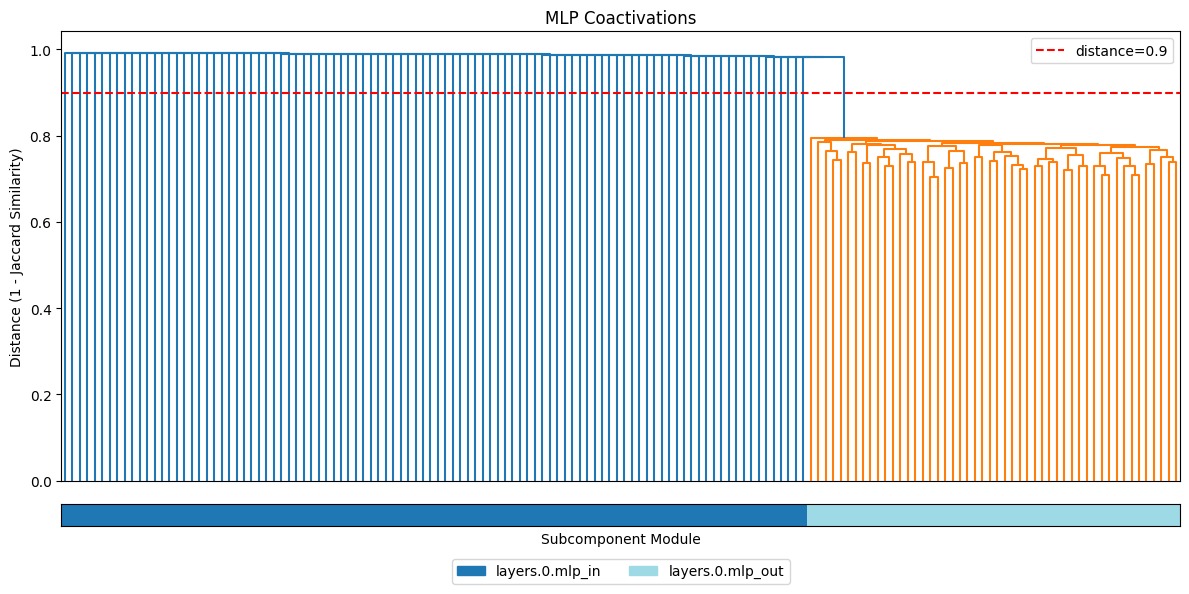

In [10]:
coactivations_mlp: CoactivationResults = get_coactivations(
    model_path=Path("../data/mlp-decomp/model_30000.pth"),
    dataset_cls=ResidualMLPDataset,
    dataset_kwargs=dict(
        calc_labels=False,  # Our labels will be the output of the target model
        label_type=None,
        act_fn_name=None,
        label_fn_seed=None,
        label_coeffs=None,
        synced_inputs=None,
    ),
    coactivations_kwargs=dict(
        module_groups=[["layers.0.mlp_in", "layers.0.mlp_out"]],
    ),
    device=DEVICE,
)
plot_clustering_from_results(
    results=coactivations_mlp,
    title="MLP Coactivations",
);

# 3 layer residual MLP

Number of alive elements: 405
Number of clusters: 113
Cluster sizes: [ 4  4  4  4  4  4  4  4  4  4  4  4  4  3  1  3  4  4  4  3  4  3  3  4
  3  2  3  4  4  4  4  3  3  3  4  3  2  4  3  4  3  1  3  1  3  1  3  2
  3  4  4  2  3  3  5  4  3  3  1  3  5  3  4  3  3  3  3  3  3  4  2  1
  3  3  3  3  3  3  3  3  3  3  4  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3 51  3  3]


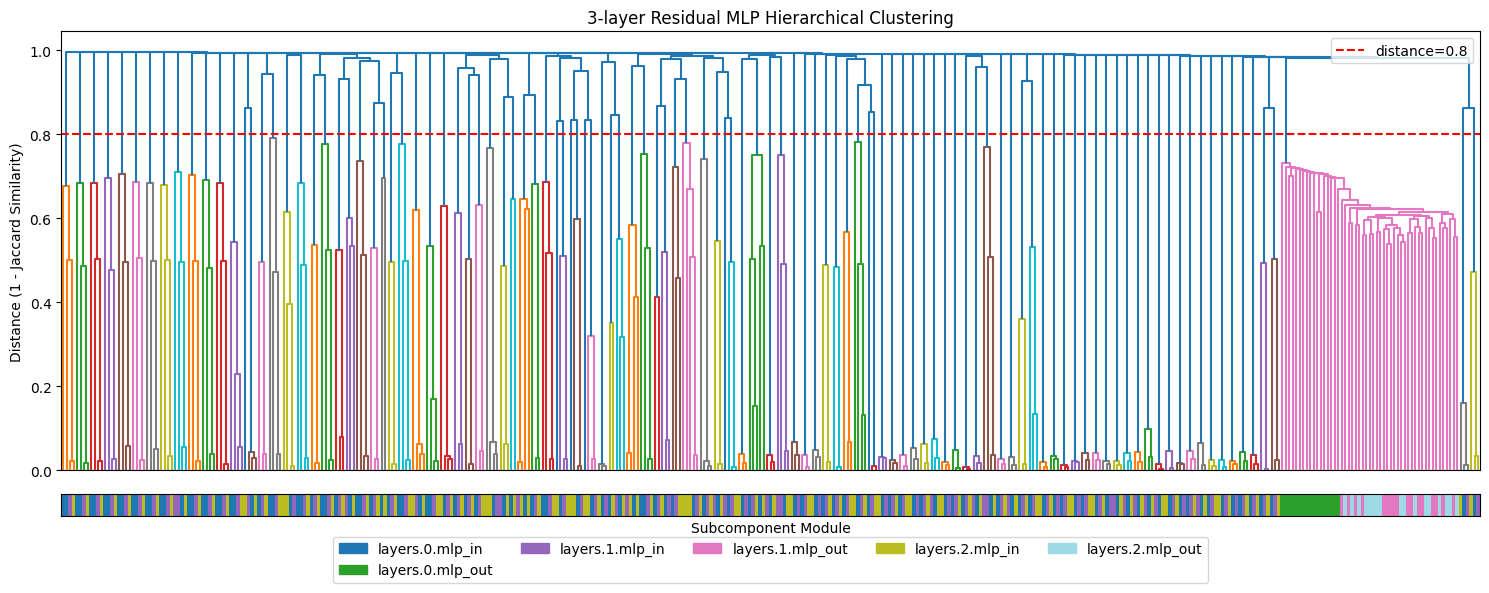

In [11]:
coactivations_mlp3: CoactivationResults = get_coactivations(
    model_path=Path("../data/mlp3-decomp/model_120000.pth"),
    dataset_cls=ResidualMLPDataset,
    dataset_kwargs=dict(
        calc_labels=False,  # Our labels will be the output of the target model
        label_type=None,
        act_fn_name=None,
        label_fn_seed=None,
        label_coeffs=None,
        synced_inputs=None,
    ),
    coactivations_kwargs=dict(
        module_groups=[
            [
                "layers.0.mlp_in",
                "layers.0.mlp_out",
                "layers.1.mlp_in",
                "layers.1.mlp_out",
                "layers.2.mlp_in",
                "layers.2.mlp_out",
            ]
        ],
    ),
    device=DEVICE,
)

_, mlp3_clusters, _, mlp3_alive_mask = plot_clustering_from_results(
    coactivations_mlp3,
    group_key="group_0",
    linkage_method="average",
    threshold=0.8,
    # linkage_method="complete",
    # threshold=0.85,
    title="3-layer Residual MLP Hierarchical Clustering",
    min_alive_counts=500,
    figsize=(15, 6),
)

In [12]:
submodules = coactivations_mlp3["group_0"]["labels"][mlp3_alive_mask]
# Get top 10 clusters by size
cluster_sizes = pd.Series(mlp3_clusters).value_counts()

for cluster_id in cluster_sizes.index[0::10]:
    cluster_mask = mlp3_clusters == cluster_id
    submodule_counts = pd.Series(submodules[cluster_mask]).value_counts()

    print(f"\nCluster {cluster_id} ({cluster_sizes[cluster_id]} elements):")
    for submodule, count in submodule_counts.items():
        print(f"  {submodule}: {count}")


Cluster 111 (51 elements):
  layers.0.mlp_out: 17
  layers.1.mlp_out: 17
  layers.2.mlp_out: 17

Cluster 28 (4 elements):
  layers.0.mlp_in: 2
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 12 (4 elements):
  layers.0.mlp_in: 2
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 10 (4 elements):
  layers.0.mlp_in: 2
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 54 (3 elements):
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 39 (3 elements):
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 43 (3 elements):
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 27 (3 elements):
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 57 (3 elements):
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 84 (3 elements):
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 47 (3 elements):
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 42 (